# Notebook 01: Baselines do Connect Four

Este notebook serve para validar os agentes de referência mais simples do projeto e confirmar que a base experimental está correta.

## Objetivo

O objetivo deste notebook é testar os dois baselines manuais do projeto:

- `random`, que escolhe ações válidas ao acaso;
- `heuristic`, que usa regras simples do jogo.

No fim, devemos perceber se o baseline heurístico é claramente superior ao aleatório e se a infraestrutura de avaliação está funcional.

## Passo 1: Preparação do ambiente

Nesta célula importamos os módulos necessários, ligamos o repositório ao `sys.path` quando preciso e definimos a pasta `outputs/`. É o ponto de arranque técnico do notebook.

In [ ]:
from __future__ import annotations

import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
NOTEBOOK_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(
    {
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_device_count": torch.cuda.device_count(),
        "device": NOTEBOOK_DEVICE,
        "cuda_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
)
OUTPUTS

from connect4_rl.agents.baselines import HeuristicAgent, RandomAgent
from connect4_rl.envs.connect_four import apply_action, initial_state, is_terminal, legal_actions, render_ascii
from connect4_rl.experiments import round_robin


## Passo 2: Configuração da experiência

Nesta célula definimos as opções principais da experiência com baselines.

- `run_baseline_tournament = True`: se estiver a `True`, o torneio entre `random` e `heuristic` é executado.
- `seed`: fixa a semente aleatória para tornar os resultados reproduzíveis.
- `games_per_pair`: número de partidas por confronto.

In [14]:
run_baseline_tournament = True

seed = 7
games_per_pair = 20

baseline_factories = {
    "random": lambda: RandomAgent(seed=seed),
    "heuristic": lambda: HeuristicAgent(seed=seed),
}


## Passo 3: Execução dos testes de baseline

Aqui corremos o torneio entre os agentes baseline. O objetivo é confirmar que o agente heurístico se comporta melhor do que o agente aleatório.

In [15]:
baseline_results = {}

if run_baseline_tournament:
    baseline_results = round_robin(baseline_factories, games_per_pair=games_per_pair)
    baseline_results
else:
    print("Set run_baseline_tournament = True to run the baseline tournament.")


## Passo 4: Análise dos resultados dos baselines

Esta célula transforma os resultados do torneio em gráficos simples de taxa de vitória e taxa de empate, para leitura rápida.

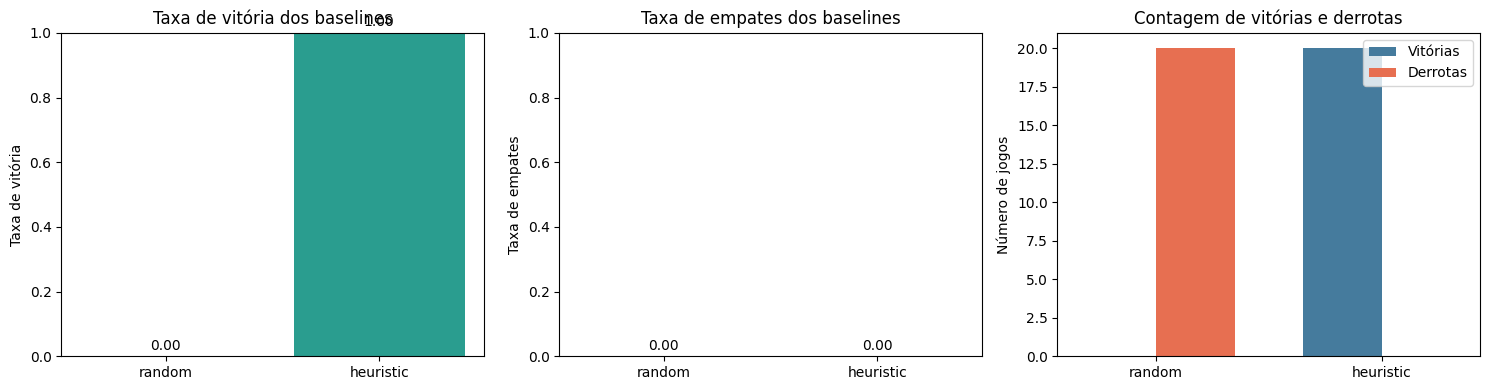

In [16]:
if baseline_results:
    labels = list(baseline_results.keys())
    win_rates = [baseline_results[name].get("win_rate", 0.0) for name in labels]
    draw_rates = [baseline_results[name].get("draw_rate", 0.0) for name in labels]
    wins = [int(baseline_results[name].get("wins", 0)) for name in labels]
    losses = [int(baseline_results[name].get("losses", 0)) for name in labels]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(labels, win_rates, color="#2a9d8f")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title("Taxa de vitória dos baselines")
    axes[0].set_ylabel("Taxa de vitória")
    for idx, value in enumerate(win_rates):
        axes[0].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    axes[1].bar(labels, draw_rates, color="#e9c46a")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title("Taxa de empates dos baselines")
    axes[1].set_ylabel("Taxa de empates")
    for idx, value in enumerate(draw_rates):
        axes[1].text(idx, value + 0.02, f"{value:.2f}", ha="center")

    x = list(range(len(labels)))
    width = 0.35
    axes[2].bar([value - width / 2 for value in x], wins, width=width, label="Vitórias", color="#457b9d")
    axes[2].bar([value + width / 2 for value in x], losses, width=width, label="Derrotas", color="#e76f51")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels)
    axes[2].set_title("Contagem de vitórias e derrotas")
    axes[2].set_ylabel("Número de jogos")
    axes[2].legend()

    fig.tight_layout()
    plt.show()


## Passo 5: Visualização de uma partida concreta

Nesta célula definimos uma função para renderizar uma partida jogada passo a passo e depois mostramos um jogo entre o heurístico e o aleatório.

In [17]:
def play_and_render(agent, opponent, controlled_player: int = 1) -> str:
    state = initial_state()
    transcript = ["Initial board", render_ascii(state), ""]
    move_idx = 0
    while not is_terminal(state):
        move_idx += 1
        if state.current_player == controlled_player:
            action = agent.select_action(state, legal_actions(state))
            actor = agent.name
        else:
            action = opponent.select_action(state, legal_actions(state))
            actor = opponent.name
        state = apply_action(state, action)
        transcript.append(f"Move {move_idx}: {actor} played column {action}")
        transcript.append(render_ascii(state))
        transcript.append("")

    transcript.append(f"Winner: {state.winner}")
    return "\n".join(transcript)

print(play_and_render(HeuristicAgent(seed=seed), RandomAgent(seed=seed), controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: random played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

Move 3: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

Move 4: random played column 1
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. O O X . . .
0 1 2 3 4 5 6

Move 5: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X . . .
. O O X . . .
0 1 2 3 4 5 6

Move 6: random played column 3
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . X . . .
. O O X . . .
0 1 2 3 4 5 6

Move 7: heuristic played column 2
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . X X 

## Passo 6: Confronto entre agentes do mesmo tipo

Aqui observamos um confronto entre dois agentes heurísticos. Isto ajuda a perceber o comportamento do baseline manual sem interferência do agente aleatório.

In [18]:
print(play_and_render(HeuristicAgent(seed=seed), HeuristicAgent(seed=seed + 1), controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 3: heuristic played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . X X . . .
0 1 2 3 4 5 6

Move 4: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . . .
. . X X . . .
0 1 2 3 4 5 6

Move 5: heuristic played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . . .
. . X X X . .
0 1 2 3 4 5 6

Move 6: heuristic played column 1
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . . .
. O X X X . .
0 1 2 3 4 5 6

Move 7: heuristic played column 5
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .

## Fecho

Se este notebook produzir resultados coerentes, então os baselines de referência estão prontos para servir de comparação aos métodos mais avançados do projeto.